# Notebook 1 — Data Loading & Understanding
**Ethiopian Household Wealth Prediction | InSy3056 | Debre Berhan University**

**CRISP-DM Phase 1 (Business Understanding) + Phase 2 (Data Understanding)**

### Objectives
- Load all 5 ESS/LSMS survey waves (W1 2011 → W5 2021), including W2 in SPSS format
- Understand survey structure: 6 modules × 5 waves × ~3 900–6 000 HH per wave
- Establish leakage-free feature set (no consumption aggregates as features)
- Explore spatial, temporal, and wealth-quintile distributions

### Leakage Rule
`cons_quint` (1=poorest → 5=wealthiest) is the **target only** — never a feature.  
Banned: `*_cons_ann`, `*_cons_aeq` columns (they define `cons_quint`).


## 1. Setup & Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Project modules
from data_loader import (build_all_waves, build_wave, wave_summary,
                         feature_coverage, coverage_by_wave,
                         explore_wave, WaveExplorer)
from data_cleaner import DataCleaner

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
print("✓ Setup complete")

✓ Setup complete


## 2. Load All 5 Waves
Modules merged per household:
- `cons_agg` → geography + demographics + target (`cons_quint`)
- `sect1` → household head (age, sex, education)
- `sect3` → labour market participation (individual → HH aggregate)
- `sect7` (W1/W2/W3) → non-farm enterprise ownership
- `sect9`/`sect8` → housing quality + asset ownership
- `sect8`/`sect9` → shock exposure (18–20 shock types, pivoted to wide)

> **W2 note**: Wave 2 (2013-14) uses SPSS `.sav` files decoded by the embedded
> `sav_reader` module (no pyreadstat required). SPSS truncates column names to
> 8 chars — `W2_COL_RENAME` in `config.py` fixes all known truncations.


In [31]:
df = build_all_waves(waves=[1,2,3,4,5], save=True, verbose=True)
print(f"\nCombined dataset: {df.shape[0]:,} households × {df.shape[1]} columns")
print(f"Waves present:    {sorted(df['wave'].unique())}")
print(f"Regions:          {sorted(df['region'].astype(str).unique())}")


════════════════════════════════════════════════════════════
Ethiopian Household Wealth — Waves: [1, 2, 3, 4, 5]
════════════════════════════════════════════════════════════

── Wave 1 (2011-12) ─────────────────
  [W1] head         merged  (3897 rows)
  [W1] labour       merged  (3969 rows)
  [W1] enterprise   merged  (3969 rows)
  [W1] housing      merged  (3969 rows)
  [W1] shocks       merged  (3969 rows)
  [W1] ✓ 3,969 households | mean missing: 2.0% | cols: 45

── Wave 2 (2013-14) ─────────────────
  [W2] head         merged  (5262 rows)
  [W2] labour       merged  (5262 rows)
  [W2] enterprise   merged  (5262 rows)
  [W2] housing      merged  (5262 rows)
  [W2] shocks       merged  (5262 rows)
  [W2] ✓ 5,262 households | mean missing: 1.3% | cols: 46

── Wave 3 (2015-16) ─────────────────
  [W3] head         merged  (4951 rows)
  [W3] labour       merged  (4951 rows)
  [W3] enterprise   merged  (4951 rows)
  [W3] housing      merged  (4951 rows)
  [W3] shocks       merged  (4951

## 3. Wave-Level Summary Table

In [17]:
summary = wave_summary(df)
summary


,wave,period,context,n_households,pct_missing,mean_quintile
0,1,2011-12,Pre-MDG baseline,3969,4.100,3.270
1,2,2013-14,High economic growth (~10% GDP/year),5262,1.300,3.390
2,3,2015-16,El Niño drought year,4954,7.600,3.330
3,4,2018-19,Pre-COVID baseline,6770,25.200,3.340
4,5,2021-22,Post-COVID + Tigray conflict,4959,29.300,3.420


## 4. Feature Coverage — Which Features Exist in Which Waves?
Coverage flags <50% (red) indicate structural absence due to wave design,
not random missingness. These are handled differently in the imputation pipeline.


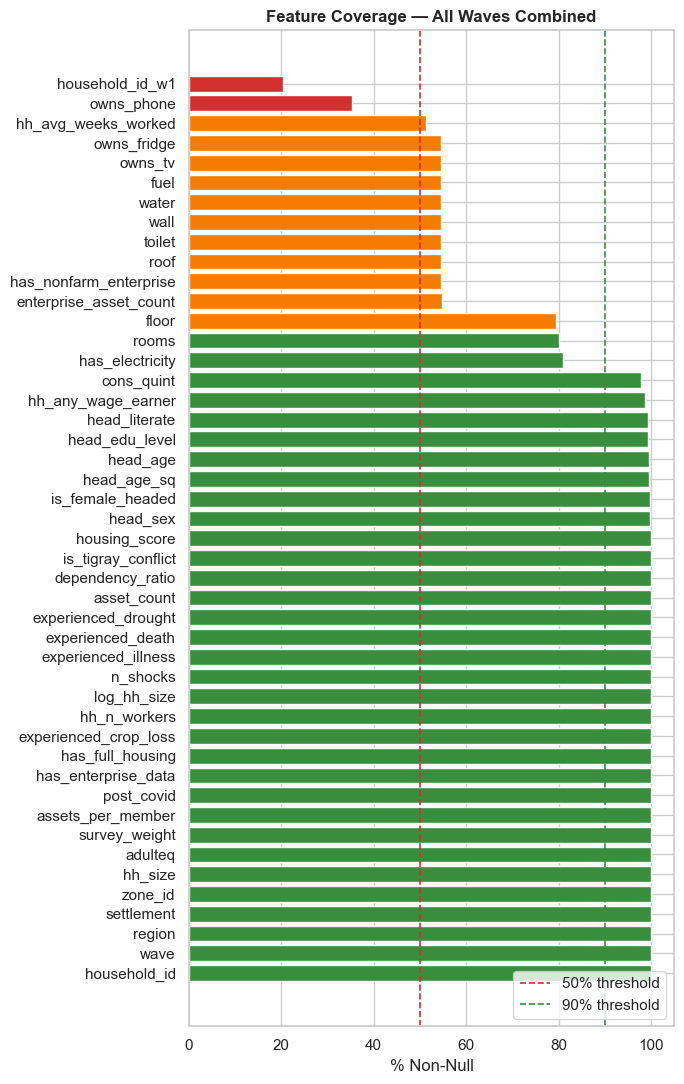

Features with <50% coverage (structural absence):
['owns_phone', 'household_id_w1']


In [18]:
# Overall non-null coverage
fc = feature_coverage(df)

fig, ax = plt.subplots(figsize=(7, 11))
colors = ['#d32f2f' if v < 50 else '#f57c00' if v < 80 else '#388e3c'
          for v in fc['pct_non_null']]
ax.barh(fc['feature'], fc['pct_non_null'], color=colors, edgecolor='white')
ax.axvline(50, color='#d32f2f', lw=1.2, ls='--', label='50% threshold')
ax.axvline(90, color='#388e3c', lw=1.2, ls='--', label='90% threshold')
ax.set_xlabel('% Non-Null')
ax.set_title('Feature Coverage — All Waves Combined', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/feature_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Features with <50% coverage (structural absence):")
print(fc[fc['pct_non_null'] < 50]['feature'].tolist())


### 4.1 Coverage Breakdown Per Wave

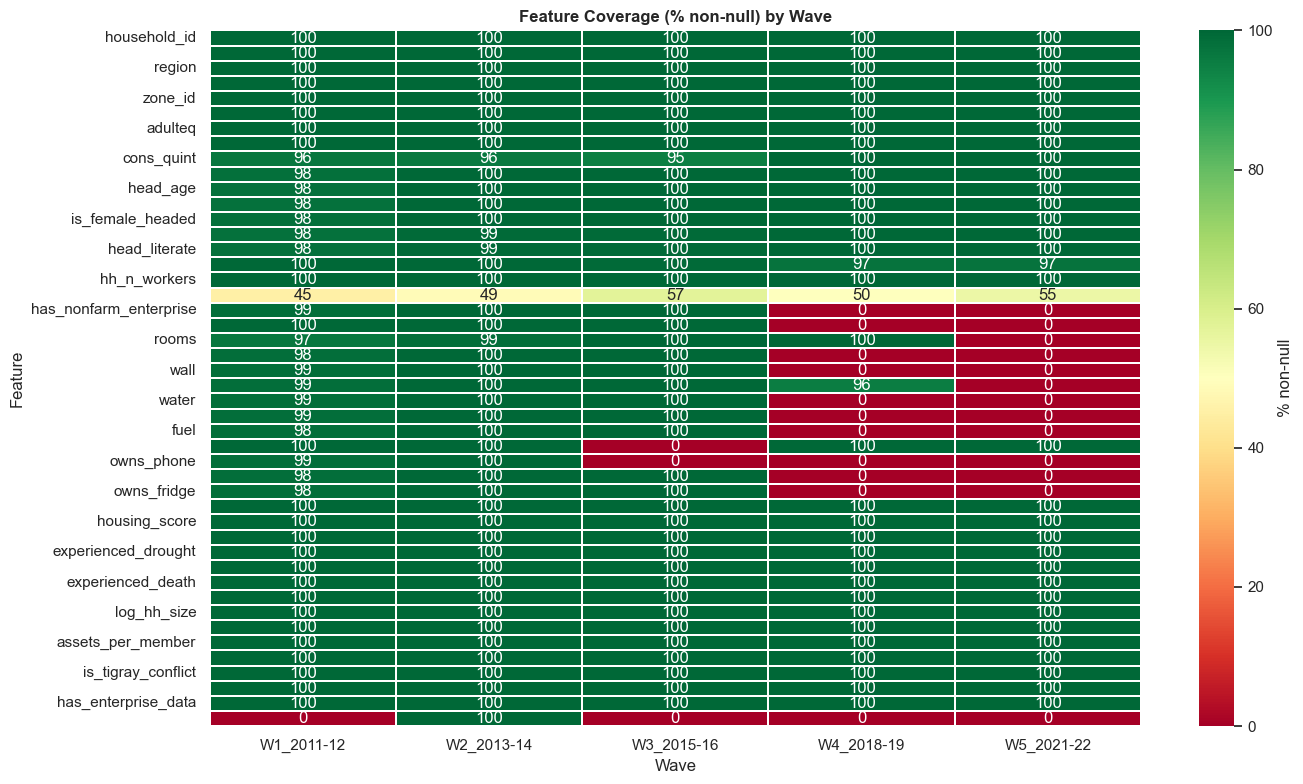

In [19]:
cov_wave = coverage_by_wave(df)
plt.figure(figsize=(14, 8))
sns.heatmap(cov_wave.T, annot=True, fmt='.0f', cmap='RdYlGn',
            linewidths=0.3, cbar_kws={'label': '% non-null'},
            vmin=0, vmax=100)
plt.title('Feature Coverage (% non-null) by Wave', fontweight='bold')
plt.xlabel('Wave'); plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../reports/wave_coverage_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Target Distribution — Wealth Quintile (cons_quint)
Class balance check. Roughly equal quintiles is expected for population-representative
surveys. Deviations indicate differential non-response across wealth groups.


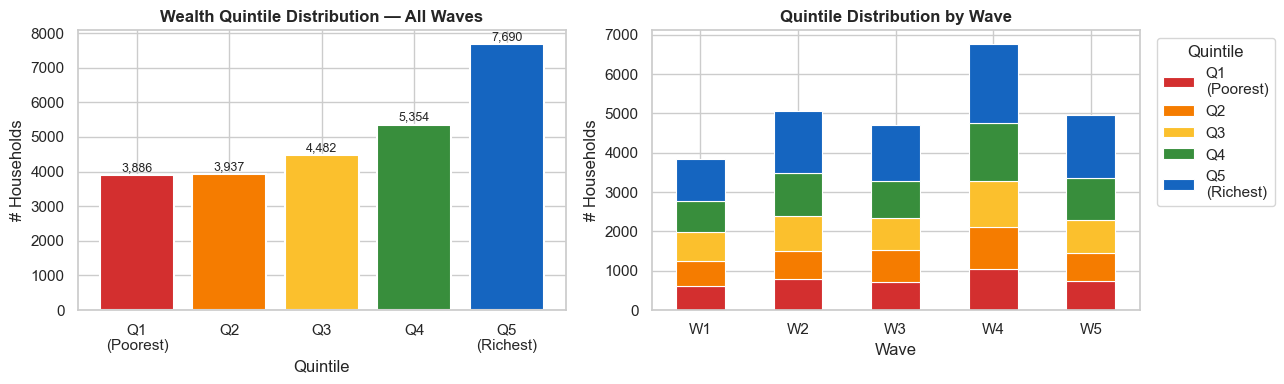

In [20]:
td = df['cons_quint'].value_counts().sort_index()
q_labels = {1:'Q1\n(Poorest)', 2:'Q2', 3:'Q3', 4:'Q4', 5:'Q5\n(Richest)'}
colors = ['#d32f2f','#f57c00','#fbc02d','#388e3c','#1565c0']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Overall distribution
bars = axes[0].bar([q_labels.get(i, str(i)) for i in td.index],
                   td.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Wealth Quintile Distribution — All Waves', fontweight='bold')
axes[0].set_xlabel('Quintile'); axes[0].set_ylabel('# Households')
for bar, n in zip(bars, td.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{n:,}', ha='center', va='bottom', fontsize=9)

# Per-wave distribution (stacked bar)
wave_q = df.groupby(['wave','cons_quint']).size().unstack(fill_value=0)
wave_q.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white',
            linewidth=0.8, stacked=True)
axes[1].set_title('Quintile Distribution by Wave', fontweight='bold')
axes[1].set_xlabel('Wave'); axes[1].set_ylabel('# Households')
axes[1].set_xticklabels([f'W{int(w)}' for w in wave_q.index], rotation=0)
axes[1].legend(title='Quintile', labels=[q_labels[i] for i in range(1,6)],
               bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig('../reports/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Geographic Distribution — Region × Settlement

In [21]:
region_stats = (
    df.groupby('region', observed=True)['cons_quint']
    .agg(n_households='count', mean_quintile='mean', std_quintile='std')
    .round(3)
    .sort_values('mean_quintile', ascending=False)
    .reset_index()
)
print("Regional wealth summary:")
region_stats


Regional wealth summary:


,region,n_households,mean_quintile,std_quintile
0,ADDIS ABABA,1946,4.103,1.101
1,HARAR,1431,4.033,1.153
2,DIRE DAWA,1627,3.804,1.236
3,TIGRAY,2223,3.529,1.381
4,AFAR,1179,3.478,1.370
5,OROMIA,4096,3.446,1.374
6,GAMBELA,1288,3.323,1.471
7,SOMALI,1909,3.194,1.444
8,BENISHANGUL GUMUZ,940,3.161,1.479
9,AMHARA,4207,2.966,1.402


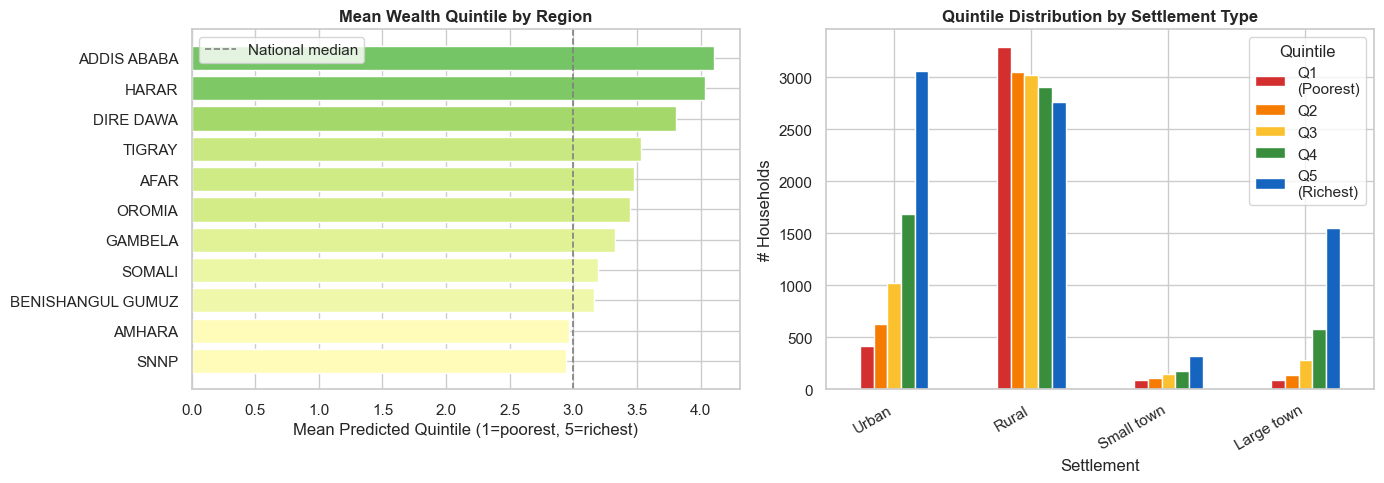

In [22]:
SETTLEMENT_LABELS = {0:'Urban', 1:'Rural', 2:'Small town', 3:'Large town'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regional mean quintile (horizontal bar chart)
rs = region_stats.sort_values('mean_quintile')
bar_clr = plt.cm.RdYlGn((rs['mean_quintile'] - 1) / 4)
axes[0].barh(rs['region'], rs['mean_quintile'], color=bar_clr, edgecolor='white')
axes[0].axvline(3, color='grey', lw=1.2, ls='--', label='National median')
axes[0].set_xlabel('Mean Predicted Quintile (1=poorest, 5=richest)')
axes[0].set_title('Mean Wealth Quintile by Region', fontweight='bold')
axes[0].legend()

# Settlement breakdown
settle_dist = (df.groupby(['settlement','cons_quint']).size()
                 .unstack(fill_value=0))
settle_dist.index = [SETTLEMENT_LABELS.get(i, str(i)) for i in settle_dist.index]
settle_dist.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Quintile Distribution by Settlement Type', fontweight='bold')
axes[1].set_xlabel('Settlement'); axes[1].set_ylabel('# Households')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].legend(title='Quintile', labels=[q_labels[i] for i in range(1,6)])
plt.tight_layout()
plt.savefig('../reports/geographic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Explore Individual Waves (WaveExplorer)
Use `WaveExplorer` to inspect any single wave or compare across waves.


In [23]:
explorer = WaveExplorer(df=df)
explorer.summary()


                                   context  n_households  pct_rural  pct_missing  mean_quintile
wave                                                                                           
1                         Pre-MDG baseline          3969     87.300        4.090          3.270
2     High economic growth (~10% GDP/year)          5262    165.100        1.270          3.390
3                     El Niño drought year          4954    159.300        7.600          3.330
4                       Pre-COVID baseline          6770     46.000       25.160          3.340
5             Post-COVID + Tigray conflict          4959     46.100       29.310          3.420


,context,n_households,pct_rural,pct_missing,mean_quintile
wave,,,,,
1,Pre-MDG baseline,3969,87.300,4.090,3.270
2,High economic growth (~10% GDP/year),5262,165.100,1.270,3.390
3,El Niño drought year,4954,159.300,7.600,3.330
4,Pre-COVID baseline,6770,46.000,25.160,3.340
5,Post-COVID + Tigray conflict,4959,46.100,29.310,3.420


In [24]:
# W2 Gap Report — shows which columns are sparse in W2 and why
explorer.w2_gap_report()



── W2 Gap Report ──────────────────────────────────────────
            feature  W2_null%  other_null%  gap_pp                                                 root_cause
hh_avg_weeks_worked    51.200       48.100   3.200   hh_s3q21_a (10ch) → hh_s3q21 in W2 SAV [LABOUR_COLS fix]
      head_literate     0.600        0.600   0.000                                Derived from head_edu_level
            zone_id     0.000        0.000   0.000                      Derived from ea_id — always available
           head_age     0.200        0.400  -0.200   hh_s1q04_a (10ch) → hh_s1q04 in W2 SAV [ROSTER_COLS fix]
        head_age_sq     0.200        0.400  -0.200                                      Derived from head_age
   is_female_headed     0.000        0.300  -0.300                                      Derived from head_sex
              rooms     1.300       24.600 -23.300 hh_s9q02_a (10ch) → hh_s9q02 in W2 SAV [W2_COL_RENAME fix]


,feature,W2_null%,other_null%,gap_pp,root_cause
5,hh_avg_weeks_worked,51.200,48.100,3.200,hh_s3q21_a (10ch) → hh_s3q21 in W2 SAV [LABOUR...
3,head_literate,0.600,0.600,0.000,Derived from head_edu_level
6,zone_id,0.000,0.000,0.000,Derived from ea_id — always available
0,head_age,0.200,0.400,-0.200,hh_s1q04_a (10ch) → hh_s1q04 in W2 SAV [ROSTER...
1,head_age_sq,0.200,0.400,-0.200,Derived from head_age
2,is_female_headed,0.000,0.300,-0.300,Derived from head_sex
4,rooms,1.300,24.600,-23.300,hh_s9q02_a (10ch) → hh_s9q02 in W2 SAV [W2_COL...


In [25]:
# Per-wave raw section inspection (returns raw DataFrames before merging)
sections = explore_wave(2)
print("W2 cons_agg columns:", sections['cons_agg'].columns.tolist()[:15])
print("W2 roster columns:  ", sections['roster'].columns.tolist()[:15])
print("W2 housing columns: ", sections['housing'].columns.tolist()[:15])


W2 cons_agg columns: ['household_id_w1', 'household_id', 'ea_id', 'ea_id2', 'saq01', 'rural', 'pw', 'adulteq', 'hh_size', 'no_conv', 'no_cons', 'food_cons_ann', 'nonfood_cons_ann', 'educ_cons_ann', 'total_cons_ann']
W2 roster columns:   ['household_id_w1', 'household_id', 'individual_id_w1', 'individual_id', 'ea_id', 'ea_id2', 'rural', 'pw', 'saq01', 'saq02', 'saq03', 'saq04', 'saq05', 'saq06', 'saq07']
W2 housing columns:  ['household_id_w1', 'household_id', 'ea_id', 'ea_id2', 'rural', 'pw', 'saq01', 'saq02', 'saq03', 'saq04', 'saq05', 'saq06', 'saq07', 'saq08', 'hh_s9q02_a']


In [26]:
# Compare housing_score across waves
explorer.compare_waves('housing_score', stat='median')



── housing_score (median) by wave ──
                                   context  median
wave                                              
1                         Pre-MDG baseline   0.519
2     High economic growth (~10% GDP/year)   0.494
3                     El Niño drought year   0.616
4                       Pre-COVID baseline   0.192
5             Post-COVID + Tigray conflict   0.000


,context,median
wave,,
1,Pre-MDG baseline,0.519
2,High economic growth (~10% GDP/year),0.494
3,El Niño drought year,0.616
4,Pre-COVID baseline,0.192
5,Post-COVID + Tigray conflict,0.000


In [27]:
# Compare electricity access trend across waves
explorer.compare_waves('has_electricity', stat='mean')



── has_electricity (mean) by wave ──
                                   context  mean
wave                                            
1                         Pre-MDG baseline 0.004
2     High economic growth (~10% GDP/year) 0.009
3                     El Niño drought year   NaN
4                       Pre-COVID baseline 0.131
5             Post-COVID + Tigray conflict 0.082


,context,mean
wave,,
1,Pre-MDG baseline,0.004
2,High economic growth (~10% GDP/year),0.009
3,El Niño drought year,NaN
4,Pre-COVID baseline,0.131
5,Post-COVID + Tigray conflict,0.082


## 8. Missing Value Report (Pre-Imputation)

In [28]:
cleaner = DataCleaner()
miss_df = cleaner.missing_report(df)
print(f"Columns with missing values: {len(miss_df)}")
miss_df.head(20)


Columns with missing values: 23


,feature,n_missing,pct_missing,dtype,recommended_strategy
0,household_id_w1,20652,79.690,str,knn or median
1,owns_phone,16742,64.610,float64,flag_and_fill(0) [MNAR]
2,hh_avg_weeks_worked,12623,48.710,float64,0 for W2 [not working]; group_impute others
3,owns_fridge,11795,45.520,float64,flag_and_fill(0) [MNAR]
4,owns_tv,11795,45.520,float64,flag_and_fill(0) [MNAR]
5,roof,11793,45.510,float64,mode by settlement
6,fuel,11794,45.510,float64,mode by settlement
7,wall,11790,45.500,float64,mode by settlement
8,has_nonfarm_enterprise,11788,45.490,float64,flag_and_fill(0) [MNAR]
9,toilet,11788,45.490,float64,mode by settlement
